In [ ]:
teacher given data

{
  "questions": [
    {
      "id": 1,
      "question_no": "Q1",
      "question": "What is Artificial Intelligence?",
      "answer": "Artificial Intelligence (AI) refers to the simulation of human intelligence in machines that are programmed to think, reason, and learn like humans. It encompasses a wide range of technologies, including machine learning, natural language processing, and computer vision.",
      "marks": 10
    },
    {
      "id": 2,
      "question_no": "Q2",
      "question": "What is Machine Learning?",
      "answer": "Machine Learning (ML) is a subset of Artificial Intelligence that focuses on building systems that can learn from data and improve their performance over time without being explicitly programmed. ML algorithms identify patterns in data and make predictions or decisions based on those patterns.",
      "marks": 10
    },
    {
      "id": 3,
      "question_no": "Q3",
      "question": "What is Deep Learning?",
      "answer": "Deep Learning is a specialized subset of machine learning that uses artificial neural networks with multiple layers (hence \"deep\") to model complex patterns in data. These neural networks are inspired by the structure of the human brain.",
      "marks": 10
    },
    {
      "id": 4,
      "question_no": "Q4",
      "question": "Explain Natural Language Processing.",
      "answer": "Natural Language Processing (NLP) is a field of artificial intelligence that focuses on the interaction between computers and human language.",
      "marks": 10
    }
  ]
}

In [ ]:
student answered data 

{
  "questions": [
    {
      "id": 1,
      "question_no": "Q1",
      "question": "What is Artificial Intelligence?",
      "answer": "Artificial Intelligence (AI) refers to the simulation of human intelligence in machines that are programmed to think, reason, and learn like human\nIt encompasses a wide range of technologies, including machine learning, natural language processing, and computer vision.\nAI systems can perform tasks such as decision-making, problem-solving, speech recognition, and language translation.\nIn modern applications, AI is used in healthcare, finance, autonomous vehicles, and recommendation systems."
    },
    {
      "id": 2,
      "question_no": "Q2",
      "question": "What is Machine Learning?",
      "answer": "Machine Learning (ML) is a subset of Artificial Intelligence that focuses on building systems that can learn from data and improve their performan\nover time without being explicitly programmed.\nML algorithms identify patterns in data and make predictions or decisions based on those patterns.\nThere are three main types of machine learning:\n1. Supervised Learning - where models are trained on labeled data.\n2. Unsupervised Learning - where models find hidden patterns in unlabeled data.\n3. Reinforcement Learning - where agents learn by interacting with an environment.\nMachine learning is widely used in spam detection, recommendation systems, and fraud detection."
    },
    {
      "id": 3,
      "question_no": "Q3",
      "question": "What is Deep Learning?",
      "answer": "Deep Learning is a specialized subset of machine learning that uses artificial neural networks with multiple layers (hence \"deep\") to model comple\npatterns in data.\nThese neural networks are inspired by the structure of the human brain.\nDeep learning models are particularly effective in handling large volumes of unstructured data such as images, audio, and text.\nCommon architectures include Convolutional Neural Networks (CNNs) for image processing and Recurrent Neural Networks (RNNs) for sequence data.\nDeep learning powers applications like image recognition, voice assistants, and self-driving cars."
    },
    {
      "id": 4,
      "question_no": "Q4",
      "question": "Explain Natural Language Processing.",
      "answer": "Natural Language Processing (NLP) is a field of artificial intelligence that focuses on the interaction between computers and human language.\nIt enables machines to understand, interpret, and generate human language in a meaningful way.\nNLP involves several tasks such as tokenization, part-of-speech tagging, named entity recognition, sentiment analysis, and machine translation.\nModern NLP systems use transformer-based architectures like BERT and GPT to achieve state-of-the-art performance.\nApplications include chatbots, virtual assistants, translation services, and text summarization systems."
    }
  ]
}

In [11]:
# models.py
from typing import List, Optional
from pydantic import BaseModel, Field
from typing_extensions import TypedDict


# ── Input schemas ──────────────────────────────────────────────────────────────

class TeacherQAItem(BaseModel):
    id: int
    question_no: str
    question: str
    answer: str
    marks: int = 10
    rubric: Optional[str] = None

class TeacherQADocument(BaseModel):
    questions: List[TeacherQAItem]


class StudentQAItem(BaseModel):
    id: int
    question_no: str
    question: Optional[str] = None
    answer: str

class StudentQADocument(BaseModel):
    questions: List[StudentQAItem]


# ── Per-question result ────────────────────────────────────────────────────────

class QuestionTags(BaseModel):
    logic: float           # 0–10
    clarity: float         # 0–10
    completeness_pct: float  # 0–100

class QuestionResult(BaseModel):
    num: str
    question: str
    awarded_score: float
    max_score: float
    compliment: str
    deduction: Optional[str]
    tags: QuestionTags


# ── Final output — maps 1:1 to assessments.ai_results JSONB ───────────────────

class AIResults(BaseModel):
    summary: str
    early_insight: str
    questions: List[QuestionResult]


# ── LangGraph state ────────────────────────────────────────────────────────────

class AssessmentState(TypedDict):
    # ── Input (you provide these) ──────────────────────────────────────────────
    teacher_doc: dict          # TeacherQADocument as plain dict
    student_doc: dict          # StudentQADocument as plain dict

    # ── Parallel node outputs ──────────────────────────────────────────────────
    question_results: list     # List[QuestionResult] as dicts
    similarity_score: float    # 0.00–100.00
    plagiarism_pct: float      # 0.00–100.00

    # ── Final output ───────────────────────────────────────────────────────────
    ai_results: dict           # AIResults as dict  → write to assessments.ai_results
    overall_score: int         # 0–100              → write to assessments.overall_score
    ai_confidence_pct: int     # 0–100              → write to assessments.ai_confidence_pct

In [ ]:
# nodes.py
import json
import re
import asyncio
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import SystemMessage, HumanMessage
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

from models import (
    AssessmentState,
    TeacherQADocument,
    StudentQADocument,
    QuestionResult,
    QuestionTags,
    AIResults,
)

# ── Clients ────────────────────────────────────────────────────────────────────

llm      = ChatAnthropic(model="claude-sonnet-4-20250514", temperature=0.2)
embedder = SentenceTransformer("all-MiniLM-L6-v2")


# ── Helper ─────────────────────────────────────────────────────────────────────

def _parse_json(text: str) -> dict:
    match = re.search(r"```json\s*(.*?)\s*```", text, re.DOTALL)
    raw = match.group(1) if match else text.strip()
    return json.loads(raw)


# ── NODE A: Evaluate every question (concurrent LLM calls) ────────────────────

async def node_evaluate_questions(state: AssessmentState) -> dict:
    teacher = TeacherQADocument(**state["teacher_doc"])
    student = StudentQADocument(**state["student_doc"])

    student_map = {q.id: q for q in student.questions}

    async def _eval_one(tq) -> dict:
        sq        = student_map.get(tq.id)
        max_marks = tq.marks

        system = f"""You are a strict but fair academic evaluator.
Score the student answer against the reference. 
Return ONLY valid JSON — no markdown, no commentary:
{{
  "awarded_score": <float 0–{max_marks}>,
  "compliment":    "<1–2 sentences on what was done well>",
  "deduction":     "<1–2 sentences on what was missing, or null if perfect>",
  "tags": {{
    "logic":            <float 0–10>,
    "clarity":          <float 0–10>,
    "completeness_pct": <float 0–100>
  }}
}}
Rubric: {tq.rubric or 'Use the reference answer as the evaluation guide.'}"""

        prompt = f"""QUESTION ({tq.question_no}): {tq.question}

REFERENCE ANSWER:
{tq.answer}

STUDENT ANSWER:
{sq.answer if sq else '[No answer provided — award 0]'}

MAX MARKS: {max_marks}"""

        resp = await llm.ainvoke([
            SystemMessage(content=system),
            HumanMessage(content=prompt),
        ])

        data = _parse_json(resp.content)

        return QuestionResult(
            num=tq.question_no,
            question=tq.question,
            awarded_score=data["awarded_score"],
            max_score=max_marks,
            compliment=data["compliment"],
            deduction=data.get("deduction"),
            tags=QuestionTags(**data["tags"]),
        ).dict()

    # All questions evaluated concurrently
    results = await asyncio.gather(*[_eval_one(tq) for tq in teacher.questions])
    return {"question_results": list(results)}


# ── NODE B: Semantic similarity score (local — no API cost) ───────────────────

async def node_compute_similarity(state: AssessmentState) -> dict:
    teacher = TeacherQADocument(**state["teacher_doc"])
    student = StudentQADocument(**state["student_doc"])

    teacher_text = " ".join(q.answer for q in teacher.questions)
    student_text = " ".join(q.answer for q in student.questions)

    def _cosine():
        t = embedder.encode([teacher_text])
        s = embedder.encode([student_text])
        return round(float(cosine_similarity(t, s)[0][0]) * 100, 2)

    score = await asyncio.to_thread(_cosine)
    return {"similarity_score": score}


# ── NODE C: Plagiarism check ───────────────────────────────────────────────────

async def node_check_plagiarism(state: AssessmentState) -> dict:
    """
    Heuristic LLM-based plagiarism signal.
    Swap for a real plagiarism API (Copyleaks, Turnitin) if needed.
    """
    student = StudentQADocument(**state["student_doc"])
    all_answers = "\n\n".join(
        f"Q{q.question_no}: {q.answer}" for q in student.questions
    )

    system = """You are a plagiarism detection assistant.
Analyse the writing style, vocabulary variety, and structural patterns of the answers.
Estimate the likelihood (0–100) that these answers were copied or paraphrased from an external source
rather than written independently.
Return ONLY valid JSON — no markdown, no commentary:
{"plagiarism_pct": <float 0–100>}
0 = clearly original. 100 = highly likely plagiarised."""

    resp = await llm.ainvoke([
        SystemMessage(content=system),
        HumanMessage(content=all_answers),
    ])

    data = _parse_json(resp.content)
    return {"plagiarism_pct": round(data["plagiarism_pct"], 2)}


# ── NODE D: Overall evaluator (runs after A + B + C finish) ───────────────────

async def node_overall_evaluator(state: AssessmentState) -> dict:
    results    = state["question_results"]
    total_got  = sum(q["awarded_score"] for q in results)
    total_max  = sum(q["max_score"]     for q in results)
    overall    = round((total_got / total_max) * 100) if total_max else 0

    results_json = json.dumps(results, indent=2)

    system = """You are a senior academic reviewer.
Given the per-question evaluations below, write a holistic assessment.
Return ONLY valid JSON — no markdown, no commentary:
{
  "summary":           "<2 sentences — overall performance>",
  "early_insight":     "<1 sentence — most notable strength or weakness>",
  "ai_confidence_pct": <integer 0–100>
}"""

    resp = await llm.ainvoke([
        SystemMessage(content=system),
        HumanMessage(content=f"RESULTS:\n{results_json}\n\nOVERALL: {overall}/100"),
    ])

    meta = _parse_json(resp.content)

    ai_results = AIResults(
        summary=meta["summary"],
        early_insight=meta["early_insight"],
        questions=[QuestionResult(**q) for q in results],
    ).dict()

    return {
        "overall_score":     overall,
        "ai_confidence_pct": meta["ai_confidence_pct"],
        "ai_results":        ai_results,
    }

In [ ]:
# graph.py
from langgraph.graph import StateGraph, START, END
from models import AssessmentState
from nodes import (
    node_evaluate_questions,
    node_compute_similarity,
    node_check_plagiarism,
    node_overall_evaluator,
)


graph = StateGraph(AssessmentState)

# ── Register nodes ─────────────────────────────────────────────────────────────
graph.add_node("evaluate_questions",  node_evaluate_questions)
graph.add_node("compute_similarity",  node_compute_similarity)
graph.add_node("check_plagiarism",    node_check_plagiarism)
graph.add_node("overall_evaluator",   node_overall_evaluator)

# ── Fan-out: all three run in parallel from START ──────────────────────────────
graph.add_edge(START, "evaluate_questions")
graph.add_edge(START, "compute_similarity")
graph.add_edge(START, "check_plagiarism")

# ── Fan-in: overall_evaluator waits for all three to finish ───────────────────
graph.add_edge("evaluate_questions", "overall_evaluator")
graph.add_edge("compute_similarity", "overall_evaluator")
graph.add_edge("check_plagiarism",   "overall_evaluator")

graph.add_edge("overall_evaluator", END)

workflow = graph.compile()

In [ ]:
# runner.py
import asyncio
import json

from graph import workflow

teacher_doc = {
    "questions": [
        {
            "id": 1, "question_no": "Q1",
            "question": "What is Artificial Intelligence?",
            "answer": "Artificial Intelligence (AI) refers to the simulation of human intelligence in machines...",
            "marks": 10
        },
        # ... rest of your questions
    ]
}

student_doc = {
    "questions": [
        {
            "id": 1, "question_no": "Q1",
            "question": "What is Artificial Intelligence?",
            "answer": "Artificial Intelligence (AI) refers to the simulation of human intelligence..."
        },
        # ... rest of your questions
    ]
}


async def main():
    initial_state = {
        "teacher_doc":      teacher_doc,
        "student_doc":      student_doc,
        # parallel outputs — start empty
        "question_results": [],
        "similarity_score": 0.0,
        "plagiarism_pct":   0.0,
        # final outputs — start empty
        "ai_results":       {},
        "overall_score":    0,
        "ai_confidence_pct": 0,
    }

    result = await workflow.ainvoke(initial_state)

    # These four fields map directly to your assessments table columns
    print("overall_score     →", result["overall_score"])
    print("ai_confidence_pct →", result["ai_confidence_pct"])
    print("similarity_score  →", result["similarity_score"])
    print("plagiarism_pct    →", result["plagiarism_pct"])
    print("ai_results        →", json.dumps(result["ai_results"], indent=2))


asyncio.run(main())

In [18]:
import asyncio
from typing import List, Optional
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

from langchain_groq import ChatGroq
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from langgraph.graph import StateGraph, START, END

# ─────────────────────────────────────────────────────────
# MODELS
# ─────────────────────────────────────────────────────────

class TeacherQAItem(BaseModel):
    id: int
    question_no: str
    question: str
    answer: str
    marks: int = 10
    rubric: Optional[str] = None


class TeacherQADocument(BaseModel):
    questions: List[TeacherQAItem]


class StudentQAItem(BaseModel):
    id: int
    question_no: str
    question: Optional[str] = None
    answer: str


class StudentQADocument(BaseModel):
    questions: List[StudentQAItem]


class QuestionTags(BaseModel):
    logic: float = Field(ge=0, le=10)
    clarity: float = Field(ge=0, le=10)
    completeness_pct: float = Field(ge=0, le=100)


class QuestionResult(BaseModel):
    num: str
    question: str
    awarded_score: float = Field(ge=0)
    max_score: float = Field(gt=0)
    compliment: str
    deduction: Optional[str]
    tags: QuestionTags


class AIResults(BaseModel):
    summary: str
    early_insight: str
    questions: List[QuestionResult]


class OverallMeta(BaseModel):
    summary: str
    early_insight: str
    ai_confidence_pct: int = Field(ge=0, le=100)


class PlagiarismSchema(BaseModel):
    plagiarism_pct: float = Field(ge=0, le=100)


class AssessmentState(TypedDict):
    teacher_doc: dict
    student_doc: dict

    question_results: list
    similarity_score: float
    plagiarism_pct: float

    ai_results: dict
    overall_score: int
    ai_confidence_pct: int


# ─────────────────────────────────────────────────────────
# LLM + EMBEDDINGS
# ─────────────────────────────────────────────────────────
from dotenv import load_dotenv
load_dotenv()


llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.1
)

embedder = SentenceTransformer("all-MiniLM-L6-v2")


# ─────────────────────────────────────────────────────────
# NODE A — QUESTION EVALUATION
# ─────────────────────────────────────────────────────────

async def node_evaluate_questions(state: AssessmentState):

    teacher = TeacherQADocument(**state["teacher_doc"])
    student = StudentQADocument(**state["student_doc"])

    structured_llm = llm.with_structured_output(QuestionResult)

    student_map = {q.id: q for q in student.questions}

    async def _eval_one(tq: TeacherQAItem):

        sq = student_map.get(tq.id)

        prompt = f"""
You are a strict academic evaluator.

Rules:
- Be precise and objective
- Do not inflate marks
- Award 0 if answer is missing
- Respect max_score strictly

Return evaluation for this:

QUESTION: {tq.question}
REFERENCE: {tq.answer}
STUDENT: {sq.answer if sq else "No answer"}
MAX_SCORE: {tq.marks}
RUBRIC: {tq.rubric or "Use reference answer"}
"""

        result = await structured_llm.ainvoke(prompt)

        return {
            **result.dict(),
            "num": tq.question_no,
            "question": tq.question,
            "max_score": tq.marks
        }

    results = await asyncio.gather(*[_eval_one(q) for q in teacher.questions])

    return {"question_results": results}


# ─────────────────────────────────────────────────────────
# NODE B — SIMILARITY
# ─────────────────────────────────────────────────────────

async def node_compute_similarity(state: AssessmentState):

    teacher = TeacherQADocument(**state["teacher_doc"])
    student = StudentQADocument(**state["student_doc"])

    t = " ".join(q.answer for q in teacher.questions)
    s = " ".join(q.answer for q in student.questions)

    def compute():
        return float(cosine_similarity(
            embedder.encode([t]),
            embedder.encode([s])
        )[0][0]) * 100

    score = await asyncio.to_thread(compute)

    return {"similarity_score": round(score, 2)}


# ─────────────────────────────────────────────────────────
# NODE C — PLAGIARISM
# ─────────────────────────────────────────────────────────

async def node_check_plagiarism(state: AssessmentState):

    student = StudentQADocument(**state["student_doc"])

    structured_llm = llm.with_structured_output(PlagiarismSchema)

    text = "\n".join(q.answer for q in student.questions)

    prompt = f"""
Estimate plagiarism likelihood (0–100).

Text:
{text}
"""

    result = await structured_llm.ainvoke(prompt)

    return {"plagiarism_pct": result.plagiarism_pct}


# ─────────────────────────────────────────────────────────
# NODE D — OVERALL
# ─────────────────────────────────────────────────────────

async def node_overall_evaluator(state: AssessmentState):

    results = state["question_results"]

    total_got = sum(q["awarded_score"] for q in results)
    total_max = sum(q["max_score"] for q in results)

    overall = round((total_got / total_max) * 100) if total_max else 0

    structured_llm = llm.with_structured_output(OverallMeta)

    prompt = f"""
Summarize performance.

Score: {overall}
Results: {results}
"""

    meta = await structured_llm.ainvoke(prompt)

    ai_results = AIResults(
        summary=meta.summary,
        early_insight=meta.early_insight,
        questions=[QuestionResult(**q) for q in results]
    )

    return {
        "overall_score": overall,
        "ai_confidence_pct": meta.ai_confidence_pct,
        "ai_results": ai_results.dict()
    }


# ─────────────────────────────────────────────────────────
# GRAPH
# ─────────────────────────────────────────────────────────

graph = StateGraph(AssessmentState)

graph.add_node("eval", node_evaluate_questions)
graph.add_node("sim", node_compute_similarity)
graph.add_node("plag", node_check_plagiarism)
graph.add_node("final", node_overall_evaluator)

graph.add_edge(START, "eval")
graph.add_edge(START, "sim")
graph.add_edge(START, "plag")

graph.add_edge("eval", "final")
graph.add_edge("sim", "final")
graph.add_edge("plag", "final")

graph.add_edge("final", END)

workflow = graph.compile()


# ─────────────────────────────────────────────────────────
# RUNNER
# ─────────────────────────────────────────────────────────

teacher_doc = {
    "questions": [
        {
            "id": 1,
            "question_no": "Q1",
            "question": "What is AI?",
            "answer": "AI simulates human intelligence",
            "marks": 10
        }
    ]
}

student_doc = {
    "questions": [
        {
            "id": 1,
            "question_no": "Q1",
            "answer": "AI is machines acting like humans"
        }
    ]
}


async def main():

    result = await workflow.ainvoke({
        "teacher_doc": teacher_doc,
        "student_doc": student_doc,
        "question_results": [],
        "similarity_score": 0,
        "plagiarism_pct": 0,
        "ai_results": {},
        "overall_score": 0,
        "ai_confidence_pct": 0,
    })

    import json
    print(json.dumps(result, indent=2))


await main()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3550.64it/s]
C:\Users\adeel\AppData\Local\Temp\ipykernel_12476\610840896.py:137: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  **result.dict(),


{
  "teacher_doc": {
    "questions": [
      {
        "id": 1,
        "question_no": "Q1",
        "question": "What is AI?",
        "answer": "AI simulates human intelligence",
        "marks": 10
      }
    ]
  },
  "student_doc": {
    "questions": [
      {
        "id": 1,
        "question_no": "Q1",
        "answer": "AI is machines acting like humans"
      }
    ]
  },
  "question_results": [
    {
      "num": "Q1",
      "question": "What is AI?",
      "awarded_score": 8.0,
      "max_score": 10,
      "compliment": "Good effort",
      "deduction": "Lacks full clarity of simulation",
      "tags": {
        "logic": 8.0,
        "clarity": 7.0,
        "completeness_pct": 80.0
      }
    }
  ],
  "similarity_score": 70.35,
  "plagiarism_pct": 20.0,
  "ai_results": {
    "summary": "The performance score is 80 with a compliment of 'Good effort' and a deduction of 'Lacks full clarity of simulation'",
    "early_insight": "The score of 80 indicates a good understanding 

C:\Users\adeel\AppData\Local\Temp\ipykernel_12476\610840896.py:228: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  "ai_results": ai_results.dict()


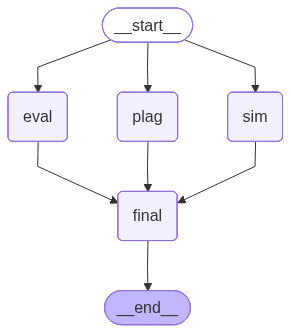

In [19]:
workflow